# Анализ big_bert: ошибки, baseline, robustness

In [1]:
# !pip install mlflow transformers spacy pandas scikit-learn matplotlib seaborn tqdm
# !python -m spacy download ru_core_news_md

In [2]:
from abc import ABC, abstractmethod
from enum import Enum
import random
import re
import pickle

import mlflow
import mlflow.sklearn
import mlflow.transformers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

MLFLOW_TRACKING_URI = "http://70.34.242.179"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

from pathlib import Path

MODELS_CACHE = Path("models_cache")
BERT_CACHE = MODELS_CACHE / "big_bert"
LOGREG_CACHE = MODELS_CACHE / "logreg"


In [3]:
class ToxicityType(str, Enum):
    INSULT = "INSULT"
    NORMAL = "NORMAL"
    OBSCENITY = "OBSCENITY"
    THREAT = "THREAT"


class BaseToxicityPredictor(ABC):
    __CLASS_MAPPING = {
        0: ToxicityType.NORMAL,
        1: ToxicityType.INSULT,
        2: ToxicityType.THREAT,
        3: ToxicityType.OBSCENITY,
    }

    def predict(self, text: str) -> ToxicityType:
        label_id = self.predict_proba(text).argmax()
        return self.__CLASS_MAPPING[label_id]

    @abstractmethod
    def predict_proba(self, text: str) -> np.ndarray:
        pass


def _cached_mlflow_load(cache_dir: Path, remote_uri: str, loader, saver, **load_kw):
    cache_dir.mkdir(parents=True, exist_ok=True)
    if (cache_dir / "MLmodel").exists():
        print(f"из кэша: {cache_dir}")
        return loader(str(cache_dir), **load_kw)
    print(f"из MLflow: {remote_uri}")
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    obj = loader(remote_uri, **load_kw)
    saver(obj, str(cache_dir))
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f"сохранено в {cache_dir}")
    return obj


class BertToxicityPredictor(BaseToxicityPredictor):
    def __init__(
        self,
        model_name="BERT_clf_dropout_DeepPavlov_rubert-base-cased-conversational",
        model_alias="final",
        cache_dir: Path = BERT_CACHE,
    ):
        remote = f"models:/{model_name}@{model_alias}"
        self.model = _cached_mlflow_load(
            cache_dir,
            remote,
            mlflow.transformers.load_model,
            mlflow.transformers.save_model,
            return_type="pipeline",
            map_location=torch.device("cpu"),
        )

    def predict_proba(self, text: str) -> np.ndarray:
        preds = self.model([text], top_k=None)[0]
        preds = sorted(preds, key=lambda item: item["label"])
        return np.array([pred["score"] for pred in preds], dtype=np.float32)


class LogRegToxicityPredictor(BaseToxicityPredictor):
    __ALLOWED_PUNCT = {"!", "?"}

    def __init__(
        self,
        model_name="baseline_logreg_bow",
        model_alias="final",
        cache_dir: Path = LOGREG_CACHE,
    ):
        self.nlp = spacy.load("ru_core_news_md")
        remote = f"models:/{model_name}@{model_alias}"
        self.model = _cached_mlflow_load(
            cache_dir,
            remote,
            mlflow.sklearn.load_model,
            mlflow.sklearn.save_model,
        )

    def __lemmatize(self, text: str) -> str:
        cleaned = []
        for token in self.nlp(text):
            if token.is_stop:
                continue
            if token.is_alpha:
                lemma = token.lemma_
                if 3 <= len(lemma) <= 30:
                    cleaned.append(lemma)
            elif token.is_punct and token.text in self.__ALLOWED_PUNCT:
                cleaned.append(token.text)
            else:
                cleaned.append(token.text)
        return " ".join(cleaned)

    def predict_proba(self, text: str) -> np.ndarray:
        lemmatized = self.__lemmatize(text)
        return self.model.predict_proba([lemmatized])[0]


In [4]:
logreg_predictor = LogRegToxicityPredictor()
big_bert_predictor = BertToxicityPredictor()


из кэша: models_cache/logreg
из кэша: models_cache/big_bert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
df = pd.read_csv("../cleaned_comments.csv", usecols=["label", "comment"])
df = df.dropna(subset=["label", "comment"])

_, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"])
print(f"Размер тестовой выборки: {len(df_test)}")
df_test["label"].value_counts()
df_eval = df_test.reset_index(drop=True)

Размер тестовой выборки: 49657


In [6]:
CLASS_NAMES = [t.value for t in ToxicityType]
CACHE_FILE = Path("results_cache.pkl")

if CACHE_FILE.exists():
    with open(CACHE_FILE, "rb") as f:
        results = pickle.load(f)
else:
    
    y_true, y_bert, y_logreg = [], [], []
    bert_probas = []

    for text, label in tqdm(
        zip(df_eval["comment"].astype(str), df_eval["label"]),
        total=len(df_eval),
        desc="inference"
    ):
        y_true.append(label)
        pb = big_bert_predictor.predict_proba(text)
        bert_probas.append(pb)
        y_bert.append(big_bert_predictor.predict(text).value)
        y_logreg.append(logreg_predictor.predict(text).value)

    results = df_eval.copy()
    results["y_true"] = y_true
    results["y_pred_bert"] = y_bert
    results["y_pred_logreg"] = y_logreg
    index_to_class = {
        0: "NORMAL",
        1: "INSULT",
        2: "THREAT",
        3: "OBSCENITY",
    }

    for i, class_name in index_to_class.items():
        results[f"p_{class_name}"] = [p[i] for p in bert_probas]

    with open(CACHE_FILE, "wb") as f:
        pickle.dump(results, f)

results.head(3)

,label,comment,y_true,y_pred_bert,y_pred_logreg,p_NORMAL,p_INSULT,p_THREAT,p_OBSCENITY
0,NORMAL,почему единственный? у пеле три выигранных финала,NORMAL,NORMAL,NORMAL,0.999336,0.000355,0.000138,0.000172
1,NORMAL,"посмотрите советские цены на продукты, лекарст...",NORMAL,NORMAL,NORMAL,0.999476,0.000236,0.000148,0.000141
2,NORMAL,я смотрю ты не уймешься.....а похоже я в точку...,NORMAL,INSULT,NORMAL,0.022774,0.973102,0.002589,0.001534


## 1. Анализ ошибок модели (BERT)

In [7]:
errors = results[results["y_true"] != results["y_pred_bert"]].copy()
errors["conf_pair"] = "true: " + errors["y_true"] + " → " + " pred: " + errors["y_pred_bert"]
proba = errors[[f"p_{c}" for c in CLASS_NAMES]].values
top2 = np.partition(proba, -2, axis=1)[:, -2:]
errors["margin"] = top2[:, 1] - top2[:, 0]

def tag_row(row):
    tags = []
    t, p = row["y_true"], row["y_pred_bert"]
    if t in {"INSULT", "THREAT", "OBSCENITY"} and p in {"INSULT", "THREAT", "OBSCENITY"} and t != p:
        tags.append("путаница подклассов токсичности")
    if t == "NORMAL" and p != "NORMAL":
        tags.append("ложная токсичность")
    if t != "NORMAL" and p == "NORMAL":
        tags.append("пропуск токсичности")
    if len(str(row["comment"]).split()) < 5:
        tags.append("короткий текст")
    if re.search(r"[a-zA-Z]{3,}", str(row["comment"])):
        tags.append("латиница")
    return tags or ["прочее"]

errors["tags"] = errors.apply(tag_row, axis=1)
print(f"Ошибок: {len(errors)} / {len(results)}, {len(errors) / len(results):.2%}")
errors["conf_pair"].value_counts().head(10)

Ошибок: 1523 / 49657, 3.07%


conf_pair
true: NORMAL →  pred: INSULT       494
true: INSULT →  pred: NORMAL       242
true: INSULT →  pred: THREAT       221
true: INSULT →  pred: OBSCENITY    125
true: NORMAL →  pred: THREAT       112
true: THREAT →  pred: INSULT       107
true: THREAT →  pred: NORMAL        63
true: OBSCENITY →  pred: INSULT     56
true: NORMAL →  pred: OBSCENITY     35
true: OBSCENITY →  pred: NORMAL     25
Name: count, dtype: int64

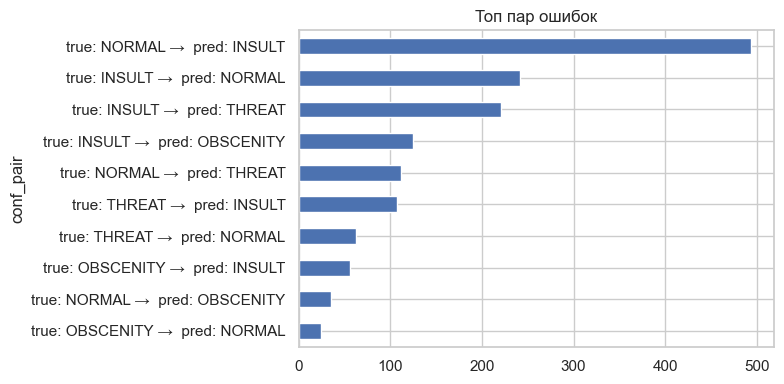

In [8]:
errors["conf_pair"].value_counts().head(10)[::-1].plot(kind="barh", figsize=(8, 4))
plt.title("Топ пар ошибок")
plt.tight_layout()
plt.show()

### Примеры ошибок

In [9]:
from IPython.display import Markdown, display

picked = []
for pair in errors["conf_pair"].value_counts().head(5).index:
    picked.append(errors[errors["conf_pair"] == pair].sort_values("margin").head(3))
examples = pd.concat(picked).drop_duplicates("comment")

for i, (_, row) in enumerate(examples.iterrows(), 1):
    top3 = sorted(
        ((c, row[f"p_{c}"]) for c in CLASS_NAMES), key=lambda x: -x[1]
    )[:3]
    proba_str = ", ".join(f"{k}: {v:.3f}" for k, v in top3)
    text = str(row["comment"])
    if len(text) > 350:
        text = text[:350] + "…"
    display(Markdown(
        f"**{i}.** {text}\n\n"
        f"True **{row['y_true']}** → Pred **{row['y_pred_bert']}** | "
        f"margin={row['margin']:.3f} | теги: {', '.join(row['tags'])}\n\n"
        f"Top-3 proba: {proba_str}\n\n"
    ))

**1.** эмилия кравец хочет сдохнуть молодой. ха ха. :d

True **NORMAL** → Pred **INSULT** | margin=0.001 | теги: ложная токсичность

Top-3 proba: INSULT: 0.438, THREAT: 0.437, NORMAL: 0.109



**2.** я что-то про москву написала? я написала про эти морды сытые и тупые.

True **NORMAL** → Pred **INSULT** | margin=0.006 | теги: ложная токсичность

Top-3 proba: INSULT: 0.502, NORMAL: 0.496, THREAT: 0.002



**3.** бизнесмен от иуды!

True **NORMAL** → Pred **INSULT** | margin=0.010 | теги: ложная токсичность, короткий текст

Top-3 proba: INSULT: 0.503, NORMAL: 0.494, THREAT: 0.001



**4.** даааа, время идёт, а идиотов, все больше и больше.....

True **INSULT** → Pred **NORMAL** | margin=0.008 | теги: пропуск токсичности

Top-3 proba: NORMAL: 0.502, INSULT: 0.494, THREAT: 0.003



**5.** эти шалашовки что умеют и для чего живут??????

True **INSULT** → Pred **NORMAL** | margin=0.011 | теги: пропуск токсичности

Top-3 proba: NORMAL: 0.504, INSULT: 0.493, OBSCENITY: 0.003



...

**11.** слушай ты в натуре что ли ишачий пидор, раз по себе всех равняешь закрой пасть хуем воняет тварь конченная.

True **INSULT** → Pred **OBSCENITY** | margin=0.006 | теги: путаница подклассов токсичности

Top-3 proba: OBSCENITY: 0.497, INSULT: 0.492, THREAT: 0.011



**12.** пускай все тебе отправят фото своего члена, вот и по росту хуя будешь определить.

True **INSULT** → Pred **OBSCENITY** | margin=0.027 | теги: путаница подклассов токсичности

Top-3 proba: OBSCENITY: 0.508, INSULT: 0.481, THREAT: 0.009



**13.** вы не представляете, как мне его хочется обозвать, когда он пытается потоптать петуха. зарезать, что то рука не поднимается.

True **NORMAL** → Pred **THREAT** | margin=0.002 | теги: ложная токсичность

Top-3 proba: THREAT: 0.486, NORMAL: 0.484, INSULT: 0.026



**14.** как полоснул, по ране бритвой........

True **NORMAL** → Pred **THREAT** | margin=0.011 | теги: ложная токсичность

Top-3 proba: THREAT: 0.497, NORMAL: 0.486, INSULT: 0.009



**15.** именно такие и митингующие......с такими требованиями , правда они это делают за деньги ....учатся новой профессии ----предателей , .... ненависников матери , которая их родила и кормит ( я о родине ) .....драть как сидоровых коз , ременякой , забытым дедовским методом , ооочень действеннен.

True **NORMAL** → Pred **THREAT** | margin=0.020 | теги: ложная токсичность

Top-3 proba: THREAT: 0.401, NORMAL: 0.381, INSULT: 0.208



**Выводы** : 
1) BERT ошибается в 3% случаев
2) Основные типы ошибок:
- Комментарий нормальный, но предсказало токсичный (42% всех ошибок)
- Перепутан тип токсичности (36% ошибок)
- Комментарий токсичный, но предсказало нормальный (22% ошибок)
3) Ошибки возникают по большему счету среди комментариев, которые либо при разметке были отнесены к неверному классу (из примеров выше: комментарии 2, 3, 15), либо которые сложно без контекста однозначно определить токсиченый или нет (комментарий 1, 4, 13, 14), либо в которых в целом можно выделить несколько типов токсичности (комментарии 7, 8, 9, 11)
4) Корректировка данных возможна только при переразметке и переходе к multi-label задаче, то есть такой, в которой один комментарий может относиться сразу к нескольким классам

## 2. Сравнение с baseline

In [10]:
def show_metrics(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print(f"F1-macro:    {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Accuracy:    {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, labels=CLASS_NAMES))


show_metrics(results["y_true"], results["y_pred_bert"], "big_bert")
show_metrics(results["y_true"], results["y_pred_logreg"], "logreg")


=== big_bert ===
F1-macro:    0.9021
F1-weighted: 0.9697
Accuracy:    0.9693
              precision    recall  f1-score   support

      INSULT       0.89      0.90      0.89      5713
      NORMAL       0.99      0.98      0.99     40736
   OBSCENITY       0.81      0.88      0.84       852
      THREAT       0.86      0.92      0.89      2356

    accuracy                           0.97     49657
   macro avg       0.89      0.92      0.90     49657
weighted avg       0.97      0.97      0.97     49657


=== logreg ===
F1-macro:    0.8245
F1-weighted: 0.9422
Accuracy:    0.9418
              precision    recall  f1-score   support

      INSULT       0.83      0.78      0.80      5713
      NORMAL       0.98      0.97      0.98     40736
   OBSCENITY       0.70      0.78      0.74       852
      THREAT       0.74      0.83      0.78      2356

    accuracy                           0.94     49657
   macro avg       0.81      0.84      0.82     49657
weighted avg       0.94      0.

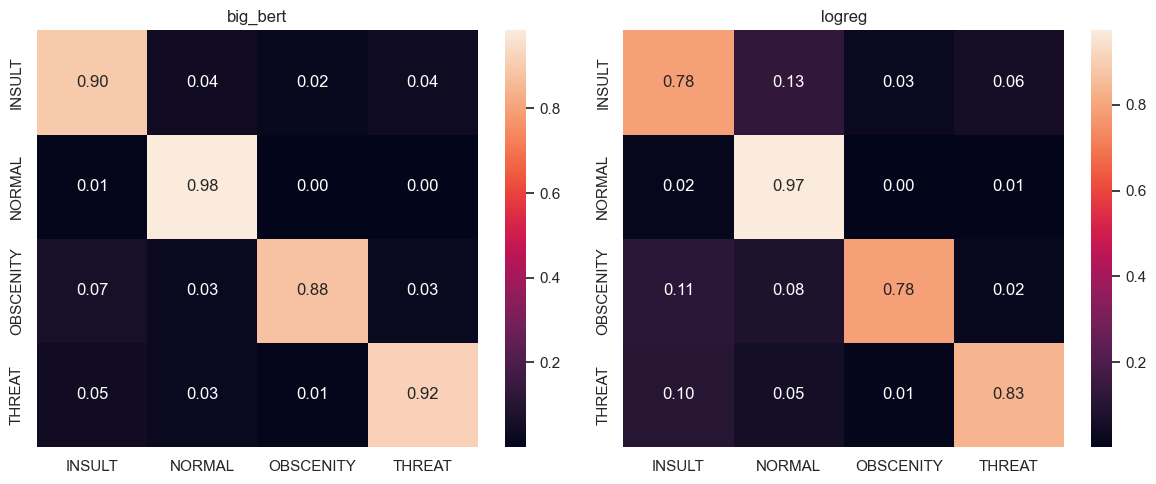

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ["y_pred_bert", "y_pred_logreg"], ["big_bert", "logreg"]):
    cm = confusion_matrix(results["y_true"], results[col], labels=CLASS_NAMES)
    sns.heatmap(
        cm.astype(float) / cm.sum(axis=1, keepdims=True),
        annot=True, fmt=".2f", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [12]:
results["bert_ok"] = results["y_true"] == results["y_pred_bert"]
results["logreg_ok"] = results["y_true"] == results["y_pred_logreg"]

bert_wins = results[results["bert_ok"] & ~results["logreg_ok"]]
logreg_wins = results[~results["bert_ok"] & results["logreg_ok"]]

print(f"BERT верен, logreg нет: {len(bert_wins)}")
print(f"logreg верен, BERT нет: {len(logreg_wins)}")
print(f"Обе ошиблись: {(~results['bert_ok'] & ~results['logreg_ok']).sum()}")

display(results.loc[bert_wins.head(5).index, ["comment", "y_true", "y_pred_bert", "y_pred_logreg"]])
display(results.loc[logreg_wins.head(5).index, ["comment", "y_true", "y_pred_bert", "y_pred_logreg"]])

BERT верен, logreg нет: 1995
logreg верен, BERT нет: 627
Обе ошиблись: 896


,comment,y_true,y_pred_bert,y_pred_logreg
8,а толку с него как с козла.как всегда у нас бы...,INSULT,INSULT,NORMAL
23,"люди,зачем вы воюете и убиваете друг друга?!ра...",NORMAL,NORMAL,THREAT
65,а пидоргвардия бздит! их тут если что и похоро...,INSULT,INSULT,NORMAL
118,не жалко пусть там и здохнет тварь,THREAT,THREAT,INSULT
160,ты ёрш чмошный слушай шуру там есть твой чмошн...,INSULT,INSULT,NORMAL


,comment,y_true,y_pred_bert,y_pred_logreg
2,я смотрю ты не уймешься.....а похоже я в точку...,NORMAL,INSULT,NORMAL
151,здорово бандиты епка,NORMAL,INSULT,NORMAL
178,"это что за сволочье - очевидцы. не поверю, что...",NORMAL,INSULT,NORMAL
254,надо же - такая молодая и такая дура! в школе ...,INSULT,NORMAL,INSULT
262,"ей место в психушке, усыплять таких сразу нужн...",NORMAL,THREAT,NORMAL


**Вывод:** 

В качестве baseline была взята модель BOW + LogisticRegression, которая довольно хорошо справилась с задачей за счет вычленения конкретных слов-триггеров (мата и т.д.). Тем не менее BERT показывает F1-macro = 0.902, что существенно выше baseline (0.8245), так как BERT удается лучше работать с контекстом и улавливать общий смысл


## 3. Проверка устойчивости (robustness)

In [ ]:
def perturb(text, kind, rng):
    if kind == "upper":
        return text.upper()
    if kind == "random_case":
        return "".join(c.upper() if rng.random() > 0.5 else c.lower() for c in text)
    if kind == "double_spaces":
        return re.sub(r" +", "  ", text)
    if kind == "no_punct":
        return re.sub(r"[!?.…,;:]", "", text)
    if kind == "typo_swap":
        chars = list(text)
        idx = [i for i, c in enumerate(chars) if c.isalpha()]
        if len(idx) >= 2:
            i, j = sorted(rng.sample(idx, 2))
            chars[i], chars[j] = chars[j], chars[i]
        return "".join(chars)
    if kind == "char_repeat":
        words = text.split()
        if words:
            i = rng.randrange(len(words))
            w = words[i]
            if len(w) > 2:
                j = rng.randrange(1, len(w) - 1)
                words[i] = w[:j] + w[j] * 2 + w[j + 1:]
        return " ".join(words)
    if kind == "emoji_insert":
        words = text.split()
        if words:
            words[rng.randrange(len(words))] += "🙂"
        return " ".join(words)
    if kind == "latin_insert":
        words = text.split()
        if words:
            w = words[rng.randrange(len(words))]
            if len(w) > 3:
                mid = len(w) // 2
                words[rng.randrange(len(words))] = w[:mid] + "x" + w[mid:]
        return " ".join(words)


pert = ["upper", "random_case", "double_spaces", "no_punct", "typo_swap", "char_repeat", "emoji_insert", "latin_insert"]

rng = random.Random(RANDOM_STATE)

rob_sample = results.groupby("y_true").apply(
    lambda g: g.sample(50, random_state=RANDOM_STATE)
).reset_index(drop=True)

flip_stats = []
for kind in pert:
    flip_count = 0
    for text in rob_sample["comment"].astype(str):
        original_pred = big_bert_predictor.predict(text).value
        perturbed_text = perturb(text, kind, rng)
        new_pred = big_bert_predictor.predict(perturbed_text).value
        flip_count += int(new_pred != original_pred)
    
    n = len(rob_sample)
    flip_stats.append({"kind": kind, "bert_flip": flip_count / n})

flip_df = pd.DataFrame(flip_stats).set_index("kind")
flip_df

/var/folders/30/86q9w0r11bg68mmtyrhpy7xc0000gn/T/ipykernel_16033/2784578.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rob_sample = results.groupby("y_true").apply(


,bert_flip
kind,
upper,0.310
random_case,0.470
double_spaces,0.000
no_punct,0.010
typo_swap,0.105
char_repeat,0.025
emoji_insert,0.065
latin_insert,0.070


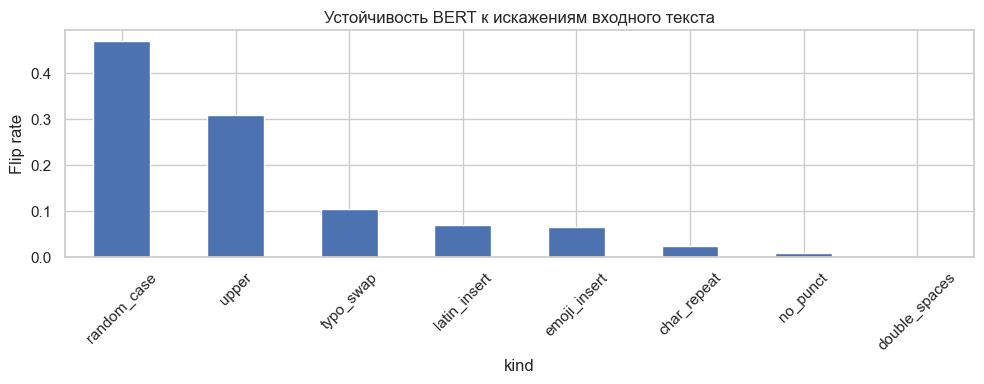

In [14]:
flip_df = flip_df.sort_values("bert_flip", ascending=False)
flip_df.plot(kind="bar", figsize=(10, 4), rot=45, legend=False)
plt.ylabel("Flip rate")
plt.title("Устойчивость BERT к искажениям входного текста")
plt.tight_layout()
plt.show()

**Выводы:** 

1) BERT очень чувствителен к смене регистра: и к переводу всего комментария в верхний регистр, и к случайному изменению регистра у отдельных букв. Вероятно, дело в том, что в датасете, на котором обучались модели, изначально все комментарии были приведены к нижнему регистру
2) Опечатки и вставки влияют умеренно: перестановка букв местами (typo_swap) изменяют прогноз модели в ~10% случаев, добавление буквы на латинице в середину комментария (latin_insert) и вставка эмодзи (emoji_insert) чуть реже
3) Остальные изменения повлияли незначительно

В целом, если учитывать особенность того, что изначальный датасет полностью в нижнем регистре и для продакшена  также передавать комментарии/сообщения, приведенных к нижнему регистру, то можно сказать, что модель устойчива